# Car Price Prediction
Steps for completing this Project
1. Loading the Dataset
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Train-validation-test split
5. Neural Network Modelling
6. Final Model + Saving

# Importing and Loading the Dataset

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
file_path = 'C:/Users/Shashank/Desktop/My Folder/My-Projects/Car_Price/car_prediction_data.csv'
data = pd.read_csv(file_path)

In [35]:
print(data.to_markdown())

|     | Car_Name                  |   Year |   Selling_Price |   Present_Price |   Kms_Driven | Fuel_Type   | Seller_Type   | Transmission   |   Owner |
|----:|:--------------------------|-------:|----------------:|----------------:|-------------:|:------------|:--------------|:---------------|--------:|
|   0 | ritz                      |   2014 |            3.35 |           5.59  |        27000 | Petrol      | Dealer        | Manual         |       0 |
|   1 | sx4                       |   2013 |            4.75 |           9.54  |        43000 | Diesel      | Dealer        | Manual         |       0 |
|   2 | ciaz                      |   2017 |            7.25 |           9.85  |         6900 | Petrol      | Dealer        | Manual         |       0 |
|   3 | wagon r                   |   2011 |            2.85 |           4.15  |         5200 | Petrol      | Dealer        | Manual         |       0 |
|   4 | swift                     |   2014 |            4.6  |           6.87  |  

# Exploratory Data Analysis (EDA)

In [31]:
# Just checking the Statistics and Data Types
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [32]:
print(data.describe())

              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [34]:
print(data.describe().to_markdown())

|       |       Year |   Selling_Price |   Present_Price |   Kms_Driven |       Owner |
|:------|-----------:|----------------:|----------------:|-------------:|------------:|
| count |  301       |       301       |       301       |        301   | 301         |
| mean  | 2013.63    |         4.6613  |         7.62847 |      36947.2 |   0.0431894 |
| std   |    2.89155 |         5.08281 |         8.64412 |      38886.9 |   0.247915  |
| min   | 2003       |         0.1     |         0.32    |        500   |   0         |
| 25%   | 2012       |         0.9     |         1.2     |      15000   |   0         |
| 50%   | 2014       |         3.6     |         6.4     |      32000   |   0         |
| 75%   | 2016       |         6       |         9.9     |      48767   |   0         |
| max   | 2018       |        35       |        92.6     |     500000   |   3         |


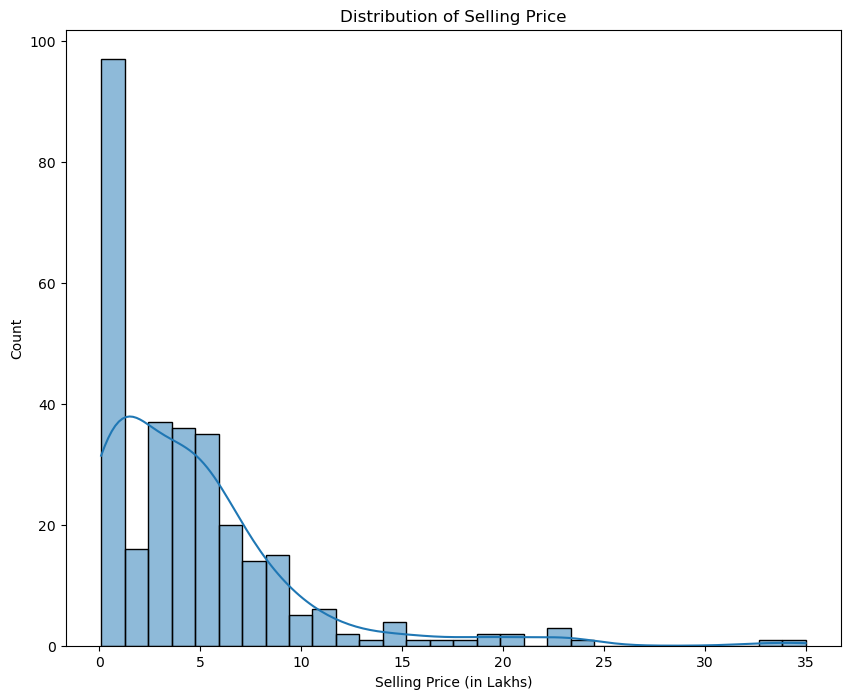

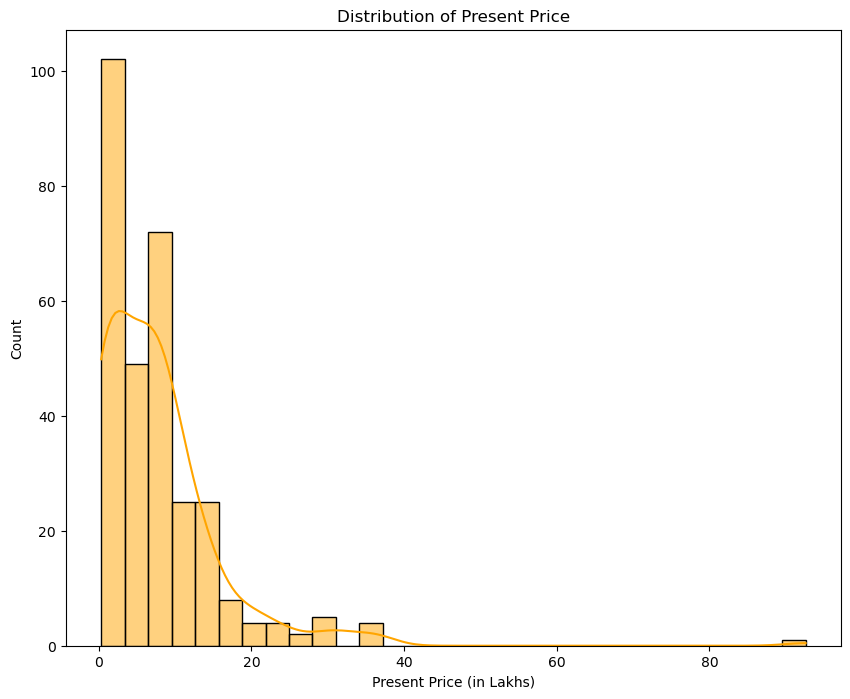

In [43]:
# Our Target Variable is Selling Price
# We will visualize the distribution of Selling Price
plt.figure(figsize = (10, 8))
sns.histplot(data['Selling_Price'], kde = True, bins = 30)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (in Lakhs)')
plt.show()

# We will also visualize the distribution of the Present Price
plt.figure(figsize = (10, 8))
sns.histplot(data['Present_Price'], kde = True, bins = 30, color = 'orange')
plt.title('Distribution of Present Price')
plt.xlabel('Present Price (in Lakhs)')
plt.show()

In [56]:
numerical_features = data.select_dtypes(include=[np.number])
correlation_output = numerical_features.corr()['Selling_Price'].sort_values(ascending=False)
print(correlation_output)

Selling_Price    1.000000
Present_Price    0.878983
Year             0.236141
Kms_Driven       0.029187
Owner           -0.088344
Name: Selling_Price, dtype: float64


In [53]:
# finding the correlation between our selling price with our other numerical features
plt.figure(figsize = (5, 5))
sns.heatmap(correlation_output, annot=True, cmap = 'coolwarm')
plt.title('Correlation Matrix')
plt.show()

IndexError: Inconsistent shape between the condition and the input (got (5, 1) and (5,))

<Figure size 500x500 with 0 Axes>

Here we can see 